# pic0rick RP2350 / RP2040 DSP test notebook

Python port of `PIC0RICK_TEST_GUIDE.md`. Instead of shelling out to
`tools/pic0rick_capture.py`, this notebook **imports its methods** and calls
them directly, and adds an Ubuntu helper to locate the board's `/dev/tty*`
port automatically (the RP2350b enumerates as a USB-CDC device, usually
`ttyACM0` or `ttyACM1`).

Run the cells top to bottom. Set `PORT` once (cell 3) and every later cell
reuses it.

## 0. Install dependencies

In [19]:
!python -m pip install -r tools/requirements.txt


[notice] A new release of pip available: 22.3.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


## 1. Imports

`pic0rick_capture` lives in `tools/`, so we add it to the path and import it
as a module. Everything the CLI does is available as functions:
`run`, `read_response_line`, `alaw_encode`, `alaw_decode`, `save_frames`,
`validate_selftest`, `FrameReader`, ...

In [20]:
import sys, time, glob
from types import SimpleNamespace
from pathlib import Path

sys.path.insert(0, 'tools')
import pic0rick_capture as pk

import serial
from serial.tools import list_ports

print('loaded pic0rick_capture from', pk.__file__)

loaded pic0rick_capture from /home/kelu/ultrasounds/pic0rick/onboard_dsp/tools/pic0rick_capture.py


## 2. Find the board's serial port (Ubuntu)

The RP2350b uses the Raspberry Pi USB vendor id `0x2E8A`. We enumerate CDC
ports, prefer any device matching that vendor id, then fall back to any
`/dev/ttyACM*`. If you get a *Permission denied* opening the port, add
yourself to the `dialout` group:

```bash
sudo usermod -aG dialout $USER   # then log out / back in
```

In [21]:
RP_VID = 0x2E8A  # Raspberry Pi (RP2040 / RP2350)

def find_pico_port(verbose=True):
    """Return the /dev/tty* path of the pic0rick, or None if not found."""
    ports = list(list_ports.comports())
    if verbose:
        if not ports:
            print('No serial ports found.')
        for p in ports:
            print(f'{p.device:16s} vid={p.vid and hex(p.vid)} '
                  f'pid={p.pid and hex(p.pid)} desc={p.description!r}')

    by_vid = [p.device for p in ports if p.vid == RP_VID]
    by_acm = [p.device for p in ports if 'ttyACM' in p.device]
    candidates = by_vid or by_acm or [p.device for p in ports]
    if not candidates:
        # last-resort glob in case pyserial missed it
        candidates = sorted(glob.glob('/dev/ttyACM*'))

    choice = candidates[0] if candidates else None
    if verbose:
        print('\n-> selected:', choice)
    return choice

PORT = find_pico_port()

/dev/ttyS31      vid=None pid=None desc='n/a'
/dev/ttyS30      vid=None pid=None desc='n/a'
/dev/ttyS29      vid=None pid=None desc='n/a'
/dev/ttyS28      vid=None pid=None desc='n/a'
/dev/ttyS27      vid=None pid=None desc='n/a'
/dev/ttyS26      vid=None pid=None desc='n/a'
/dev/ttyS25      vid=None pid=None desc='n/a'
/dev/ttyS24      vid=None pid=None desc='n/a'
/dev/ttyS23      vid=None pid=None desc='n/a'
/dev/ttyS22      vid=None pid=None desc='n/a'
/dev/ttyS21      vid=None pid=None desc='n/a'
/dev/ttyS20      vid=None pid=None desc='n/a'
/dev/ttyS19      vid=None pid=None desc='n/a'
/dev/ttyS18      vid=None pid=None desc='n/a'
/dev/ttyS17      vid=None pid=None desc='n/a'
/dev/ttyS16      vid=None pid=None desc='n/a'
/dev/ttyS15      vid=None pid=None desc='n/a'
/dev/ttyS14      vid=None pid=None desc='n/a'
/dev/ttyS13      vid=None pid=None desc='n/a'
/dev/ttyS12      vid=None pid=None desc='n/a'
/dev/ttyS11      vid=None pid=None desc='n/a'
/dev/ttyS10      vid=None pid=None

### Text-command and capture helpers

`send_text` sends a single line command and dumps whatever the firmware
replies for a short window (good for `status`, `help`, `dac`, `pulse`,
`dsp scale`). `capture` builds the same namespace the CLI's `argparse`
produces and calls `pk.run(...)` directly.

In [22]:
def send_text(command, port=None, wait=1.0, timeout=0.3):
    """Send one text command; print and return everything received in `wait` s."""
    port = port or PORT
    with serial.Serial(port, 115200, timeout=timeout) as s:
        s.reset_input_buffer(); s.reset_output_buffer()
        s.write((command + '\n').encode('ascii')); s.flush()
        deadline = time.monotonic() + wait
        buf = bytearray()
        while time.monotonic() < deadline:
            chunk = s.read(256)
            if chunk:
                buf.extend(chunk)
    text = buf.decode('ascii', errors='replace').strip()
    print(text)
    return text


def capture(mode='alaw', rate=0, frames=1, timeout=30.0,
            output='captures', selftest=False, port=None):
    """Import-and-run wrapper around pic0rick_capture.run() (equivalent to the
    CLI). timeout defaults to 30 s (the CLI's --timeout)."""
    args = SimpleNamespace(
        port=port or PORT,
        mode=mode,
        rate=int(rate),
        frames=int(frames),
        timeout=float(timeout),
        output=Path(output),
        selftest=bool(selftest),
    )
    rc = pk.run(args)
    print('exit code:', rc)
    return rc

### Serial exchange logging

Mirror every byte to/from the board into a `.log` file. Lines we **send** are
prefixed with `$ `; lines we **receive** have no prefix. Binary frame payloads
are summarised as `[N binary bytes]` so the log stays readable. We patch
`serial.Serial`, so both `send_text()` and the imported `pk.run()` are logged.
Call `set_log('captures/other.log')` to switch files.

In [23]:
LOG_PATH = Path('captures/session.log')
_log_bufs = {'tx': bytearray(), 'rx': bytearray()}
_LOG_MAXLINE = 4096

def set_log(path):
    """Choose the log file and write a session header."""
    global LOG_PATH
    LOG_PATH = Path(path)
    LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(LOG_PATH, 'a') as f:
        f.write(f'# --- session {time.strftime("%Y-%m-%d %H:%M:%S")} ---\n')
    print('logging serial to', LOG_PATH.resolve())
    return LOG_PATH

def _log_flush_line(direction, line):
    line = line.rstrip(b'\r')
    printable = sum(1 for b in line if b in (9, 10, 13) or 32 <= b <= 126)
    if line and printable / len(line) < 0.85:
        text = f'[{len(line)} binary bytes]'
    else:
        text = line.decode('ascii', errors='replace')
    if direction == 'rx' and text == '':
        return
    prefix = '$ ' if direction == 'tx' else ''
    with open(LOG_PATH, 'a') as f:
        f.write(prefix + text + '\n')

def _log_bytes(direction, data):
    if not data:
        return
    buf = _log_bufs[direction]
    buf.extend(data)
    while True:
        nl = buf.find(b'\n')
        if nl >= 0:
            line = bytes(buf[:nl]); del buf[:nl + 1]
            _log_flush_line(direction, line)
        elif len(buf) >= _LOG_MAXLINE:
            line = bytes(buf[:_LOG_MAXLINE]); del buf[:_LOG_MAXLINE]
            _log_flush_line(direction, line)
        else:
            break

_BaseSerial = serial.Serial

class LoggingSerial(_BaseSerial):
    """serial.Serial that mirrors all traffic into LOG_PATH."""
    def write(self, data):
        _log_bytes('tx', bytes(data))
        return super().write(data)
    def read(self, size=1):
        data = super().read(size)
        _log_bytes('rx', data)
        return data

# Patch the module so BOTH send_text() and pic0rick_capture.run() are logged.
serial.Serial = LoggingSerial
set_log(LOG_PATH)

logging serial to /home/kelu/ultrasounds/pic0rick/onboard_dsp/captures/session.log


PosixPath('captures/session.log')

## 3. Boot and command check

Keep the high-voltage pulser supply disabled. Expected `status` includes:
`board=pic0rick package=RP2040 samples=4096 sample_rate=60000000 pulser=disarmed`.
`help` lists acquisition / streaming / DSP / DAC / pulser commands (no MAX14866).

In [24]:
send_text('status')

OK board=pic0rick package=RP2350A firmware=1.6 dsp_backend=f32-rfft-hilbert samples=4096 sample_rate=60000000 pulser=disarmed pulse=96/6000/96/neg-first dac=0 scale=512.000 stream=off/0 drops=0 stages_us=0/0/0/0/0/0 dsp_us=0 worst_us=0 performance=ok envelope_max_rate=50 alaw_max_rate=70 cmsis=1.17.0


'OK board=pic0rick package=RP2350A firmware=1.6 dsp_backend=f32-rfft-hilbert samples=4096 sample_rate=60000000 pulser=disarmed pulse=96/6000/96/neg-first dac=0 scale=512.000 stream=off/0 drops=0 stages_us=0/0/0/0/0/0 dsp_us=0 worst_us=0 performance=ok envelope_max_rate=50 alaw_max_rate=70 cmsis=1.17.0'

In [25]:
send_text('help', wait=1.5)

OK commands=status|help|pulser arm|pulser disarm|pulse config <negative_ns> <damp_ns> <positive_ns> <neg-first|pos-first>|dac write <0..1023>|dsp scale <reference>|dsp selftest|acq <raw|envelope|alaw>|stream start <raw|envelope|alaw> <rate_hz>|stream stop|start acq|read


'OK commands=status|help|pulser arm|pulser disarm|pulse config <negative_ns> <damp_ns> <positive_ns> <neg-first|pos-first>|dac write <0..1023>|dsp scale <reference>|dsp selftest|acq <raw|envelope|alaw>|stream start <raw|envelope|alaw> <rate_hz>|stream stop|start acq|read'

## 4. DSP self-test

Captures 21 deterministic frames (7 signals x raw/envelope/A-law) and
compares the firmware against `scipy.signal.hilbert`. Pass = 21 frames, no
CRC/sequence error, normalized envelope RMS <= 1e-4, peak within 1 sample,
A-law within 1 level, exit code 0.

In [26]:
capture(selftest=True, output='captures/selftest',timeout=30)

OK board=pic0rick package=RP2350A firmware=1.6 dsp_backend=f32-rfft-hilbert samples=4096 sample_rate=60000000 pulser=disarmed pulse=96/6000/96/neg-first dac=0 scale=512.000 stream=off/0 drops=0 stages_us=0/0/0/0/0/0 dsp_us=0 worst_us=0 performance=ok envelope_max_rate=50 alaw_max_rate=70 cmsis=1.17.0
OK selftest frames=21 cases=7
1/21: seq=0 type=raw flags=0x0008 drops=0 peak=0
2/21: seq=1 type=envelope flags=0x0008 drops=0 peak=0
3/21: seq=2 type=alaw flags=0x0008 drops=0 peak=0
4/21: seq=3 type=raw flags=0x0108 drops=0 peak=0
5/21: seq=4 type=envelope flags=0x0108 drops=0 peak=0
6/21: seq=5 type=alaw flags=0x0108 drops=0 peak=0
7/21: seq=6 type=raw flags=0x0208 drops=0 peak=0
8/21: seq=7 type=envelope flags=0x0208 drops=0 peak=200.7
9/21: seq=8 type=alaw flags=0x0208 drops=0 peak=200.7
10/21: seq=9 type=raw flags=0x0308 drops=0 peak=0
11/21: seq=10 type=envelope flags=0x0308 drops=0 peak=314.02
12/21: seq=11 type=alaw flags=0x0308 drops=0 peak=314.02
13/21: seq=12 type=raw flags=0x04

0

## 5. ADC and physical-signal checks

With the pulser disarmed, capture the ADC input in each format. Each call is a
fresh physical acquisition. Headers (ADC mean, envelope peak, CRC, ...) are in
`headers.json` alongside the `.npy` files.

In [27]:
for value in (0, 512, 1023):
    send_text(f'dac write {value}')

OK dac=0
OK dac=512
OK dac=1023


In [28]:
capture(mode='raw',      output='captures/raw',timeout=60)

OK board=pic0rick package=RP2350A firmware=1.6 dsp_backend=f32-rfft-hilbert samples=4096 sample_rate=60000000 pulser=disarmed pulse=96/6000/96/neg-first dac=1023 scale=512.000 stream=off/0 drops=0 stages_us=539/4810/134/4704/1085/383 dsp_us=11662 worst_us=12069 performance=over-budget envelope_max_rate=50 alaw_max_rate=70 cmsis=1.17.0
OK capture started type=raw
1/1: seq=21 type=raw flags=0x0000 drops=0 peak=0
exit code: 0


0

In [29]:
capture(mode='envelope', output='captures/envelope')

OK board=pic0rick package=RP2350A firmware=1.6 dsp_backend=f32-rfft-hilbert samples=4096 sample_rate=60000000 pulser=disarmed pulse=96/6000/96/neg-first dac=1023 scale=512.000 stream=off/0 drops=0 stages_us=0/0/0/0/0/0 dsp_us=0 worst_us=0 performance=ok envelope_max_rate=50 alaw_max_rate=70 cmsis=1.17.0
OK capture started type=envelope
1/1: seq=22 type=envelope flags=0x0000 drops=0 peak=225.49
exit code: 0


0

In [30]:
# Set the A-law full-scale reference (ADC counts) before an A-law capture.
# Default after reboot is 512.
send_text('dsp scale 512')
capture(mode='alaw', output='captures/alaw')

OK scale=512.000
OK board=pic0rick package=RP2350A firmware=1.6 dsp_backend=f32-rfft-hilbert samples=4096 sample_rate=60000000 pulser=disarmed pulse=96/6000/96/neg-first dac=1023 scale=512.000 stream=off/0 drops=0 stages_us=536/4554/135/4731/1079/0 dsp_us=11039 worst_us=12069 performance=over-budget envelope_max_rate=50 alaw_max_rate=70 cmsis=1.17.0
OK capture started type=alaw
1/1: seq=23 type=alaw flags=0x0000 drops=0 peak=201.58
exit code: 0


0

### Inspect a capture

The saved arrays are plain NumPy; load and plot one frame.

raw (1, 4096) envelope (1, 4096)


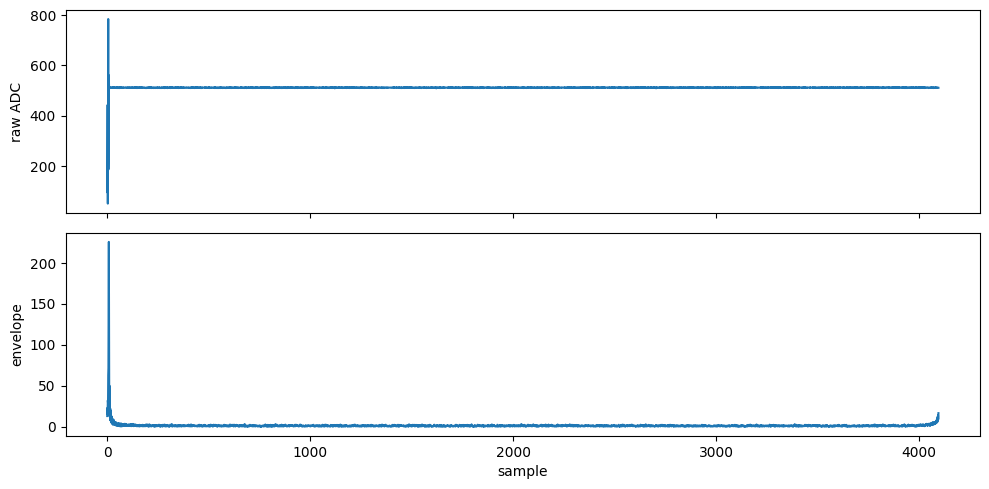

In [31]:
import numpy as np
import matplotlib.pyplot as plt

raw = np.load('captures/raw/raw.npy')          # shape (frames, 4096)
env = np.load('captures/envelope/envelope.npy')
print('raw', raw.shape, 'envelope', env.shape)

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax[0].plot(raw[0]);  ax[0].set_ylabel('raw ADC')
ax[1].plot(env[0]);  ax[1].set_ylabel('envelope')
ax[1].set_xlabel('sample')
plt.tight_layout(); plt.show()

## 6. DAC check

With a scope/voltmeter on the analog test point. Each valid write returns
`OK dac=<value>`. Check GPIO13 (CS), GPIO14 (2 MHz clock), GPIO15 (MOSI) if
the level is wrong.

In [32]:
for value in (0, 512, 1023):
    send_text(f'dac write {value}')

OK dac=0
OK dac=512
OK dac=1023


## 7. Pulser logic check

**Keep high voltage disabled.** Inspect GPIO11 (P+), GPIO12 (P-), GPIO16
(PDAMP), GPIO17 (OE) with a logic analyzer.

Negative-first order expects: P-/OE high 96 ns, then PDAMP/OE high 6000 ns,
then P+/OE high 96 ns, then all low. Durations round to the nearest 8 ns PIO
tick; minimum stage is 40 ns.

In [33]:
send_text('pulse config 96 6000 96 neg-first')
send_text('pulser arm')
capture(mode='raw', output='captures/pulse-neg')

OK pulse=96/6000/96/neg-first
OK pulser armed
OK board=pic0rick package=RP2350A firmware=1.6 dsp_backend=f32-rfft-hilbert samples=4096 sample_rate=60000000 pulser=armed pulse=96/6000/96/neg-first dac=1023 scale=512.000 stream=off/0 drops=0 stages_us=537/4545/136/4713/1080/692 dsp_us=11710 worst_us=12069 performance=over-budget envelope_max_rate=50 alaw_max_rate=70 cmsis=1.17.0
OK capture started type=raw
1/1: seq=24 type=raw flags=0x0010 drops=0 peak=0
exit code: 0


0

In [34]:
# Other order: P+ and P- swap positions.
send_text('pulse config 96 6000 96 pos-first')
capture(mode='raw', output='captures/pulse-pos')
send_text('pulser disarm')

OK pulse=96/6000/96/pos-first
OK board=pic0rick package=RP2350A firmware=1.6 dsp_backend=f32-rfft-hilbert samples=4096 sample_rate=60000000 pulser=armed pulse=96/6000/96/pos-first dac=1023 scale=512.000 stream=off/0 drops=0 stages_us=0/0/0/0/0/0 dsp_us=0 worst_us=0 performance=ok envelope_max_rate=50 alaw_max_rate=70 cmsis=1.17.0
OK capture started type=raw
1/1: seq=25 type=raw flags=0x0010 drops=0 peak=0
exit code: 0
OK pulser disarmed


'OK pulser disarmed'

raw (1, 4096) envelope (1, 4096)


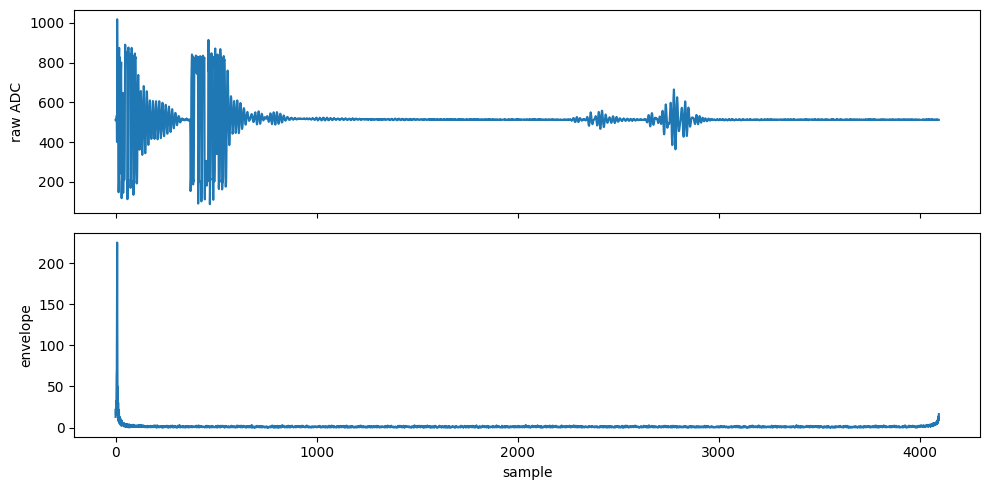

In [39]:
import numpy as np
import matplotlib.pyplot as plt

raw = np.load('captures/pulse-pos/raw.npy')          # shape (frames, 4096)
env = np.load('captures/envelope/envelope.npy')
print('raw', raw.shape, 'envelope', env.shape)

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax[0].plot(raw[0]);  ax[0].set_ylabel('raw ADC')
ax[1].plot(env[0]);  ax[1].set_ylabel('envelope')
ax[1].set_xlabel('sample')
plt.tight_layout(); plt.show()

## 8. Streaming and timing

Raw frames are limited to 100 Hz; envelope/A-law to 5 Hz on this RP2040 build.
Higher rates return `ERR RATE`. After stopping, the tool saves `status.txt`;
require `drops=0`. The status line reports per-stage microseconds
(`stages_us=...`, `dsp_us=`, `worst_us=`).

In [35]:
# One frame per second for a minute.
capture(mode='alaw', rate=1, frames=60, output='captures/alaw-1hz')

OK board=pic0rick package=RP2350A firmware=1.6 dsp_backend=f32-rfft-hilbert samples=4096 sample_rate=60000000 pulser=disarmed pulse=96/6000/96/pos-first dac=1023 scale=512.000 stream=off/0 drops=0 stages_us=0/0/0/0/0/0 dsp_us=0 worst_us=0 performance=ok envelope_max_rate=50 alaw_max_rate=70 cmsis=1.17.0
OK stream started type=alaw rate=1
1/60: seq=26 type=alaw flags=0x0000 drops=0 peak=218.57
2/60: seq=27 type=alaw flags=0x0000 drops=0 peak=230.5
3/60: seq=28 type=alaw flags=0x0000 drops=0 peak=206.53
4/60: seq=29 type=alaw flags=0x0000 drops=0 peak=228.14
5/60: seq=30 type=alaw flags=0x0000 drops=0 peak=220.16
6/60: seq=31 type=alaw flags=0x0000 drops=0 peak=230.09
7/60: seq=32 type=alaw flags=0x0000 drops=0 peak=217.67
8/60: seq=33 type=alaw flags=0x0000 drops=0 peak=207.4
9/60: seq=34 type=alaw flags=0x0000 drops=0 peak=205.13
10/60: seq=35 type=alaw flags=0x0000 drops=0 peak=219.35
11/60: seq=36 type=alaw flags=0x0000 drops=0 peak=228.48
12/60: seq=37 type=alaw flags=0x0000 drops=0

0

In [40]:
print(Path('captures/alaw-1hz/status.txt').read_text())

OK board=pic0rick package=RP2350A firmware=1.6 dsp_backend=f32-rfft-hilbert samples=4096 sample_rate=60000000 pulser=disarmed pulse=96/6000/96/pos-first dac=1023 scale=512.000 stream=off/1 drops=0 stages_us=538/4392/137/4751/1066/689 dsp_us=11579 worst_us=12069 performance=over-budget envelope_max_rate=50 alaw_max_rate=70 cmsis=1.17.0



In [ ]:
# Compiled limit: 5 Hz for 5 minutes.
# capture(mode='alaw', rate=5, frames=300, output='captures/alaw-5hz')
# print(Path('captures/alaw-5hz/status.txt').read_text())